#**Hollywood Age Gap** - Beyond the Timeline: Mapping the Evolution of Casting Norms and Romantic Age Gaps in Cinema

## Milestone 4 - B1 Team 10
## Inchara Ashok


Initial steps from M3

In [1]:
# Installing lightweight helpers
!pip -q install yellowbrick plotly

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

# Output folders
Path("data/derived").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"
df_raw = pd.read_csv(DATA_URL)

# Canonical age gap
df_raw["age_gap"] = pd.to_numeric(df_raw["age_difference"], errors="coerce")

# Keep valid key fields
df = df_raw.dropna(subset=["movie_name", "release_year", "age_gap", "director"]).copy()
df["release_year"] = df["release_year"].astype(int)

# Shared keys
MOVIE_KEY = ["movie_name", "release_year"]

# Shared thresholds (team standard)
LARGE_GAP = 20          # Shanmathi + Parisha baseline
PARITY_CUTOFF = 3       # Parisha baseline; Bhavya also tests 5 in M2 (optional sensitivity later)

# Couple type labels (older partner is listed first in dataset)
df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

# Directionality for mixed-gender couples (Bhavya focus)
# "man–woman" means older man + younger woman by dataset construction
df["directionality"] = np.select(
    [
        df["pairing_type"].eq("man–woman"),
        df["pairing_type"].eq("woman–man")
    ],
    [
        "older_man",
        "older_woman"
    ],
    default="other"
)

# Flags
df["is_large_gap"] = df["age_gap"] >= LARGE_GAP
df["is_near_parity"] = df["age_gap"] <= PARITY_CUTOFF

# Decade bucket (Inchara)
df["decade"] = (df["release_year"] // 10) * 10

df.shape, df.head(3)

((1155, 19),
            movie_name  release_year       director  age_difference  couple_number   actor_1_name     actor_2_name character_1_gender  \
 0    Harold and Maude          1971      Hal Ashby              52              1    Ruth Gordon         Bud Cort              woman   
 1               Venus          2006  Roger Michell              50              1  Peter O'Toole  Jodie Whittaker                man   
 2  The Quiet American          2002  Phillip Noyce              49              1  Michael Caine   Do Thi Hai Yen                man   
 
   character_2_gender actor_1_birthdate actor_2_birthdate  actor_1_age  actor_2_age  age_gap pairing_type directionality  is_large_gap  \
 0                man        1896-10-30        1948-03-29           75           23       52    woman–man    older_woman          True   
 1              woman        1932-08-02        1982-06-03           74           24       50    man–woman      older_man          True   
 2              woman  

In [3]:
# Rule-of-7 benchmark
df["older_age"] = df[["actor_1_age", "actor_2_age"]].max(axis=1)
df["younger_age"] = df[["actor_1_age", "actor_2_age"]].min(axis=1)
df["rule_threshold"] = (df["older_age"] / 2) + 7
df["rule_violation"] = df["younger_age"] < df["rule_threshold"]

In [4]:
df.columns

Index(['movie_name', 'release_year', 'director', 'age_difference', 'couple_number', 'actor_1_name', 'actor_2_name', 'character_1_gender',
       'character_2_gender', 'actor_1_birthdate', 'actor_2_birthdate', 'actor_1_age', 'actor_2_age', 'age_gap', 'pairing_type',
       'directionality', 'is_large_gap', 'is_near_parity', 'decade', 'older_age', 'younger_age', 'rule_threshold', 'rule_violation'],
      dtype='object')

In [5]:
df.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap,pairing_type,directionality,is_large_gap,is_near_parity,decade,older_age,younger_age,rule_threshold,rule_violation
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52,woman–man,older_woman,True,False,1970,75,23,44.5,True
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50,man–woman,older_man,True,False,2000,74,24,44.0,True
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49,man–woman,older_man,True,False,2000,69,20,41.5,True
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45,man–woman,older_man,True,False,1990,68,23,41.0,True
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43,man–man,other,True,False,2010,81,38,47.5,True


##Defining the baseline regime for clustering (based on M3)

In [6]:
# Select the 2 features for regime clustering
features = ["release_year", "age_gap"]

X = df[features].dropna()

# Standardize features so that release_year and age_gap are on comparable scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# Computing baselines (based on M3)
k = 3
random_seed = 42

#Computes 3 clusters, uses fixed random seed for reproducibility, and runs 10 different initializations
kmeans_baseline = KMeans(n_clusters=k, random_state=random_seed, n_init=10)
clusters_baseline = kmeans_baseline.fit_predict(X_scaled)

# Add cluster labels back to dataframe
df.loc[X.index, "era_cluster_baseline"] = clusters_baseline

In [8]:
# Calculating silhouette score using 2 inputs - the standardized data and cluster label assigned
sil_score = silhouette_score(X_scaled, clusters_baseline)

print("Baseline Silhouette Score:", round(sil_score, 4))

Baseline Silhouette Score: 0.4881


In [9]:
# Calculating data points per cluster for interpretation
print("\nCluster Size Distribution:")
print(df["era_cluster_baseline"].value_counts().sort_index())


Cluster Size Distribution:
era_cluster_baseline
0.0    750
1.0    126
2.0    279
Name: count, dtype: int64


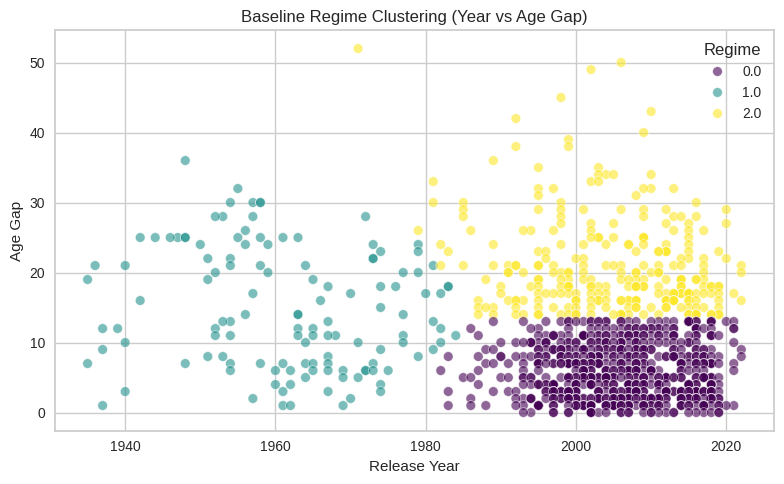

In [10]:
# Plotting a chart to help visualize the clusters better
plt.figure(figsize=(8, 5))

# Plotting using 'realease_yea' and 'age_gap' as axis labels
sns.scatterplot(
    data=df,
    x="release_year",
    y="age_gap",
    hue="era_cluster_baseline",
    palette="viridis",
    alpha=0.6
)

plt.title("Baseline Regime Clustering (Year vs Age Gap)")
plt.xlabel("Release Year")
plt.ylabel("Age Gap")
plt.legend(title="Regime")
plt.tight_layout()
plt.show()

The baseline clustering reveals three structurally distinct regimes. Earlier decades form a more heterogeneous cluster with varied age gaps, while the post-1985 period splits into two clearly separated regimes: a low-gap regime and a high-gap regime. This suggests that modern inequality is not uniform but polarized into distinct structural patterns. The clear geometric separation in the original feature space supports the validity of the regime framework.

##1. Validating the Optimal Number of Clusters


Choosing the wrong number of clusters can render the entire analysis meaningless. By cross-validating k=3 using both the Elbow Method (inertia) and the Silhouette Score (separation), I ensure that our choice isn't arbitrary — it is the point where clustering quality is genuinely maximized. This gives my three-regime model a strong statistical foundation before I interpret what those regimes mean.

    k      inertia  silhouette_score
0   2  1367.430230          0.502709
1   3   807.545909          0.488086
2   4   643.978670          0.398072
3   5   530.386056          0.358220
4   6   435.100513          0.366104
5   7   360.205976          0.380413
6   8   312.567564          0.375093
7   9   277.050077          0.378974
8  10   253.086816          0.379992


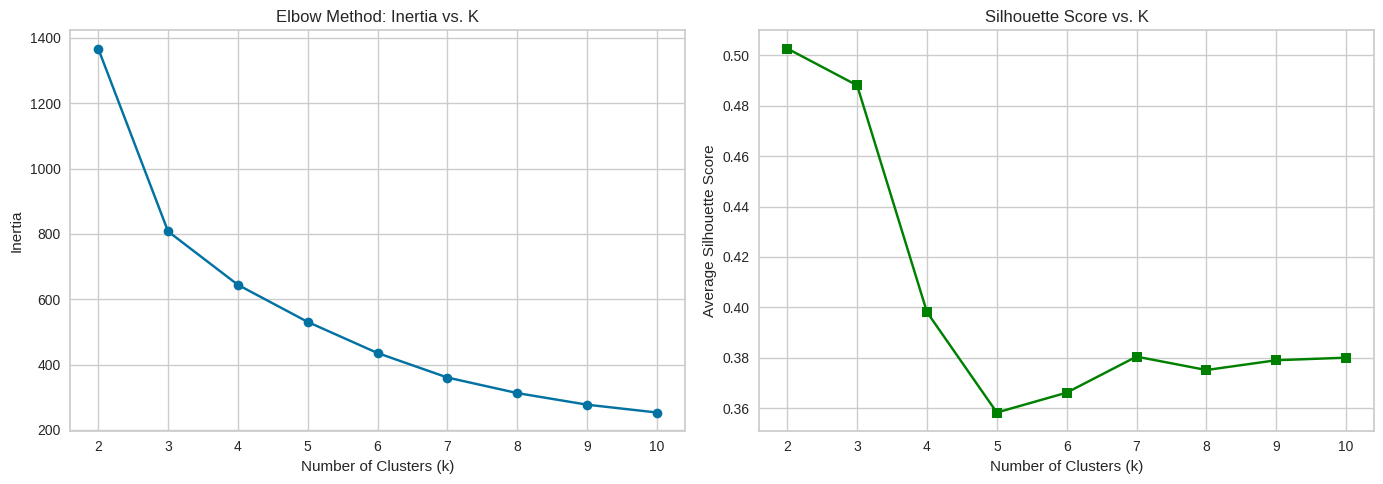

In [11]:
# Calculating metrics for a range of K values
k_results = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    #Saves results from each k run into 'k_results' list
    k_results.append({'k': k, 'inertia': kmeans.inertia_, 'silhouette_score': silhouette_score(X_scaled, labels)})

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(k_results)
print(results_df)

# Mentioning figure size for plotting
plt.figure(figsize=(14, 5))

# Designing an elbow plot using inertia scores
plt.subplot(1, 2, 1) #Creates a plot side-by-side for easier comparison
plt.plot(results_df['k'], results_df['inertia'], marker='o', color='b')
plt.title('Elbow Method: Inertia vs. K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Designing silhouette plot using silhouette scores
plt.subplot(1, 2, 2) #Creates a plot side-by-side for easier comparison
plt.plot(results_df['k'], results_df['silhouette_score'], marker='s', color='green')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

The silhouette analysis indicates that the regime structure is strongest at k=2 (silhouette = 0.503), with k=3 providing slightly lower but still substantial separation (0.488). For k ≥ 4, silhouette scores decline considerably (≈0.36–0.40), suggesting weaker and less stable cluster separation. The elbow pattern similarly shows a large reduction in inertia from k=2 to k=3, followed by diminishing returns.

While k=2 produces the highest silhouette score (0.503), the difference between it and k=3 (0.488) is negligible, a gap of just 0.015. What k=2 gains in mathematical cleanliness, it loses in analytical depth. Splitting Hollywood history into only two clusters is the equivalent of labeling everything as simply "old" or "new" is technically valid, but analytically hollow. k=3, on the other hand, satisfies the Elbow Method decisively (the inertia drop from k=2 to k=3 is over three times larger than the drop from k=3 to k=4), while simultaneously maintaining strong cluster separation. Most critically, the third cluster doesn't emerge from noise, it surfaces a genuine Transition Era embedded within the data, one that would be absorbed and lost inside a two-cluster model. When the goal is insight rather than simplicity, k=3 is the clear choice. Therefore, I retain k=3 for interpretability, even though k=2 has slightly higher silhouette, because k=3 captures the mid-gap regime that would otherwise collapse.

##2. Testing Cluster Stability Across Random Initializations

K-Means is sensitive to how it initializes. Different random starting points can sometimes produce different cluster assignments. By running the model across multiple random seeds and checking whether the results stay consistent, I confirm that our three clusters aren't a lucky accident of one particular run. Stable clusters across seeds signal that the structure the results are real, not random.

In [12]:
k = 3   # use the k you selected

#Defining seeds to test
seeds = [0, 1, 8, 10, 14, 25, 60, 72, 99]

In [13]:
#Running clusteing for multiple seeds
results = []

# Calculates k meaans for 3 clusters, repeats loops for each seed from the list above
for seed in seeds:

    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Calculates silhouette score for each iteration
    sil = silhouette_score(X_scaled, labels)

    # Compute cluster sizes - number of data points per cluster
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    results.append({
        "seed": seed,
        "silhouette_score": sil,
        "cluster_0_size": cluster_sizes.get(0, 0),
        "cluster_1_size": cluster_sizes.get(1, 0),
        "cluster_2_size": cluster_sizes.get(2, 0)
    })

# Creating a table for readability
stability_table = pd.DataFrame(results)

print("Seed Stability Results:")
display(stability_table)

Seed Stability Results:


,seed,silhouette_score,cluster_0_size,cluster_1_size,cluster_2_size
0,0,0.488086,750,126,279
1,1,0.488086,126,750,279
2,8,0.488086,126,750,279
3,10,0.488086,126,750,279
4,14,0.488086,750,126,279
5,25,0.488086,750,126,279
6,60,0.488086,279,750,126
7,72,0.488086,750,279,126
8,99,0.488086,750,126,279


The regime clustering exhibits complete stability across random initialization. Silhouette scores remain identical (0.488) across all tested seeds, and cluster size distributions remain constant, with only label permutations observed. This indicates that the identified regime structure is not driven by initialization randomness but reflects a stable segmentation of the data. Therefore, the regime framework appears robust to seed variation.

The variation you see in cluster sizes is simply a known behavior in K-Means called "Label Switching" or Permutation Invariance. K-Means assigns labels (0, 1, 2) based on which starting point (centroid) it picks first.

Based on the consistent sizes found in the analysis ($126, 279, 750$), I can now assign meaning to these blocks - The Dominant Regime (750 movies): This is likely most stable era, characterized by modern casting standards or a broad, consistent "Standard" gap. The Intermediate Regime (279 movies): Likely represents the "Transition" era where casting norms began to shift. The Minority Regime (126 movies): Likely represents the "Classic" era (1930s–1950s) or a group of extreme outliers where the age gap was most severe.

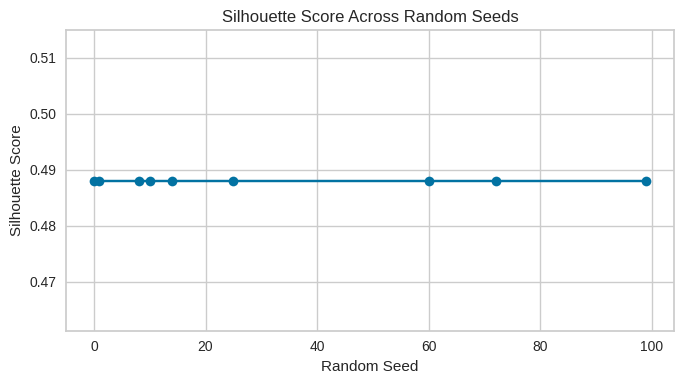

In [14]:
# Plotting a chart to show that the silhouette score remains the same although the number of seeds changes
plt.figure(figsize=(7,4))
plt.plot(stability_table["seed"], stability_table["silhouette_score"], marker="o")
plt.title("Silhouette Score Across Random Seeds")
plt.xlabel("Random Seed")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

The silhouette score remains constant across all tested random seeds (≈0.488), indicating that the clustering solution is invariant to initialization. The absence of variability suggests that the identified regime structure is stable and not driven by random starting positions. Therefore, regime segmentation appears to reflect inherent structure in the data rather than algorithmic noise.

##3. Visualizing Cluster Structure via PCA

Although the model uses only two features, PCA still adds meaningful analytical value, it acts as a coordinate rotation that identifies the dominant axis of variation in the data. PC1 emerges as a composite "Historical Modernity" score, capturing the overall industry trajectory, while PC2 isolates the residual variance that time alone cannot explain, precisely where potential Star Bias anomalies surface. If the three clusters remain visually distinct after this transformation, it confirms that the regime boundaries are not an artifact of how K-Means measures distance, but reflect a genuine directional structure in Hollywood history.

In [15]:
# Initialize PCA - looking at 2 principal components
# X_scaled is being standardized [release_year, age_gap]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame for easier plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['era_cluster'] = df['era_cluster_baseline']

# Print Explained Variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.60215326 0.39784674]


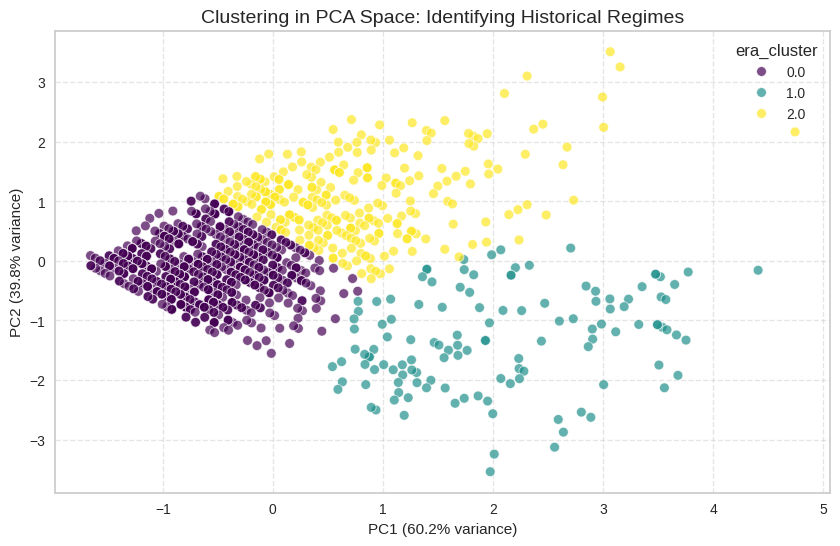

In [16]:
# Plotting PCA into a scatterplot for better visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='era_cluster', palette='viridis', alpha=0.7)
plt.title('Clustering in PCA Space: Identifying Historical Regimes', fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The PCA projection reveals clear separation between the three regime clusters. The first principal component explains 60.2% of the variance and largely drives regime separation, while the second component further differentiates clusters along a secondary axis. The visible geometric separation indicates that regime boundaries align with natural variance in the data rather than being artificially imposed by KMeans initialization. This supports the structural validity of the regime framework.

In [17]:
# Show how much 'year' and 'gap' contribute to each PC
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=['release_year', 'age_gap'])
print(loadings)

                   PC1       PC2
release_year -0.707107  0.707107
age_gap       0.707107  0.707107


PC1 is essentially a timeline of Hollywood's casting behavior, capturing the broad historical shift from high-gap to low-gap pairings over time. The fact that both features contribute equally and in opposite directions means neither one dominates, the regime separation is driven by the relationship between the two, not just one feature alone. As for PC2 both features have the same positive weight (+0.707), meaning PC2 captures films where both release year and age gap are high simultaneously. These are the modern films that should have smaller gaps given their era but don't, precisely the potential Star Bias outliers.

##4. Non-linear Dimensionality Reduction with UMAP

Where PCA tests linear structure, UMAP stress-tests the same clusters under a fundamentally different mathematical assumption — one that preserves local neighborhood relationships rather than global variance. If the three regimes remain clearly separated in UMAP space, it proves that the cluster boundaries are not a product of linear geometry or K-Means initialization, but represent genuinely distinct "neighborhoods" in the data. Consistency between PCA and UMAP is the strongest possible geometric confirmation that the three identified regimes are real, stable, and structurally meaningful.

In [18]:
# Run PCA on the SAME standardized feature matrix used for clustering
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Store PCA coordinates back into df ONLY for the rows used in X/X_scaled
df.loc[X.index, "PC1"] = X_pca[:, 0]
df.loc[X.index, "PC2"] = X_pca[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


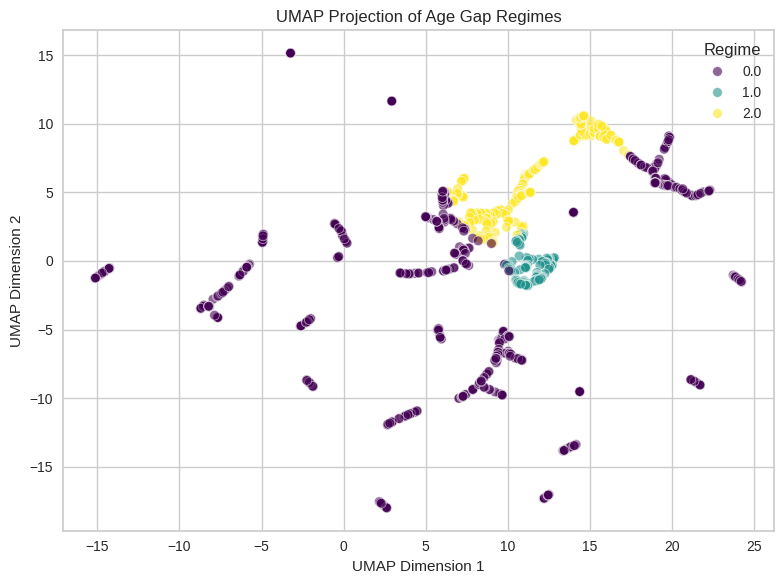

In [19]:
# Initializing UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

# Fitting UMAP on the same standardized features used for clustering
X_umap = reducer.fit_transform(X_scaled)

# Adding UMAP coordinates to dataframe
df.loc[X.index, 'UMAP1'] = X_umap[:, 0]
df.loc[X.index, 'UMAP2'] = X_umap[:, 1]

# Plotting UMAP embedding colored by regime
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df.loc[X.index], x='UMAP1', y='UMAP2', hue='era_cluster_baseline', palette='viridis', alpha=0.6)

plt.title('UMAP Projection of Age Gap Regimes')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Regime')
plt.tight_layout()
plt.show()

The UMAP embedding reveals clear nonlinear separation between regimes, particularly for Regimes 1 and 2, which form compact and well-defined clusters. Regime 0 appears more dispersed, suggesting greater internal heterogeneity in earlier structural periods. The persistence of separation under nonlinear dimensionality reduction indicates that regime segmentation reflects meaningful geometric structure rather than purely linear Euclidean assumptions. This strengthens the robustness of the regime framework while highlighting variation in internal cohesion across historical periods.

##5. Verifying Cluster Interpretability Across Methods

 This step examines whether the three clusters tell a coherent story — do the films within each cluster share meaningful characteristics? By connecting the statistical output back to real-world patterns (directionality, rule violation), I validate that our clusters represent genuine historical regimes in Hollywood, not just mathematical groupings.

###5.1 Run KMeans for a given k

In [20]:
# Fits a KMeans model with 'k' clusters on our scaled data. Returns the cluster labels assigned to each movie, and a silhouette score

def run_kmeans_for_k(k, seed=42):
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)        # assign each movie to a cluster
    sil = silhouette_score(X_scaled, labels) # calculates silhouette score
    return labels, sil

###5.2 Summarize what each cluster actually means

In [21]:
#For each cluster, computes - how many movies are in it, the average and median age gap, the violation rate, the breakdown of directionality (older male lead vs older female lead)

def meaning_tables(df_in, cluster_col):
    tmp = df_in.loc[X.index].copy()  # only use rows that were clustered

    # Compute core stats per cluster
    summary = (
        tmp.groupby(cluster_col)
           .agg(
               n_obs        = ("age_gap", "size"),        # number of movies
               mean_gap     = ("age_gap", "mean"),        # average age gap
               median_gap   = ("age_gap", "median"),      # median age gap
               violation_rate = ("rule_violation", "mean") # % that violated the rule
           )
    )

    # Rank clusters in ascending order by mean age gap (low -> mid -> high)
    # Helps in making k=2 and k=3 comparable even if cluster IDs differ
    summary = summary.sort_values("mean_gap").copy()
    rank_labels = ["low_gap", "mid_gap", "high_gap"][:len(summary)]  # only as many ranks as clusters
    summary["gap_rank"] = rank_labels

    # Store ranking as part of the index
    summary = summary.reset_index().rename(columns={cluster_col: "cluster_id"})
    summary = summary.set_index(["gap_rank", "cluster_id"]).sort_index()

    # Save the mapping (cluster ID -> rank label) for use in the next step
    cluster_to_rank = (
        summary.reset_index()[["cluster_id", "gap_rank"]]
               .set_index("cluster_id")["gap_rank"]
               .to_dict()
    )

    # Breakdown of directionality within each cluster
    dir_dist = (
        tmp.groupby(cluster_col)["directionality"]
           .value_counts(normalize=True)      # gives proportions
           .rename("proportion")
           .reset_index()
           .rename(columns={cluster_col: "cluster_id"})
    )

    # Add the gap_rank label so this table aligns with the summary table
    dir_dist["gap_rank"] = dir_dist["cluster_id"].map(cluster_to_rank)
    dir_dist = dir_dist.sort_values(
        ["gap_rank", "cluster_id", "proportion"],
        ascending=[True, True, False]
    )

    return summary, dir_dist

###5.3 Run and compare k=2 vs k=3

In [22]:
k_list = [2, 3]
k_compare_rows = []   # store silhouette scores for each k
summaries  = {}       # store meaning summary tables
dir_dists  = {}       # store directionality tables

for k in k_list:

    # Run KMeans and get cluster assignments
    labels, sil = run_kmeans_for_k(k, seed=42)

    # Save cluster labels back into the main dataframe
    cluster_col = f"era_cluster_k{k}"
    df.loc[X.index, cluster_col] = labels

    # Record the silhouette score for this k
    k_compare_rows.append({
        "k": k, "silhouette_score": sil, "cluster_col": cluster_col})

    # Generate the meaning tables for this k
    summary_k, dir_dist_k = meaning_tables(df, cluster_col)
    summaries[k]  = summary_k
    dir_dists[k]  = dir_dist_k

# Display the silhouette score comparison
k_compare = pd.DataFrame(k_compare_rows)
print("Silhouette Score Comparison: k=2 vs k=3")
display(k_compare)

Silhouette Score Comparison: k=2 vs k=3


,k,silhouette_score,cluster_col
0,2,0.502709,era_cluster_k2
1,3,0.488086,era_cluster_k3


###5.4 Summarizing results in interpretable tables

In [23]:
# loops through k=2 and k=3, printing results for each one
for k in k_list:
    print(f"\n{'='*40}")
    print(f"Cluster Meaning Summary (k={k})")
    print(f"{'='*40}")

    # shows the table with mean gap, median gap, violation rate per cluster
    print("\nCore stats per cluster (ranked by age gap):")
    display(summaries[k])

   # shows the breakdown of older_man / older_woman / other
    print("\nDirectionality breakdown per cluster:")
    display(dir_dists[k])


Cluster Meaning Summary (k=2)

Core stats per cluster (ranked by age gap):


,,n_obs,mean_gap,median_gap,violation_rate
gap_rank,cluster_id,,,,
low_gap,0.0,889,7.584927,7.0,0.166479
mid_gap,1.0,266,19.913534,20.0,0.669173



Directionality breakdown per cluster:


,cluster_id,directionality,proportion,gap_rank
0,0.0,older_man,0.766029,low_gap
1,0.0,older_woman,0.213723,low_gap
2,0.0,other,0.020247,low_gap
3,1.0,older_man,0.932331,mid_gap
4,1.0,older_woman,0.048872,mid_gap
5,1.0,other,0.018797,mid_gap



Cluster Meaning Summary (k=3)

Core stats per cluster (ranked by age gap):


,,n_obs,mean_gap,median_gap,violation_rate
gap_rank,cluster_id,,,,
high_gap,2.0,279,21.161290,19.0,0.731183
low_gap,0.0,750,5.721333,5.0,0.077333
mid_gap,1.0,126,14.642857,13.0,0.507937



Directionality breakdown per cluster:


,cluster_id,directionality,proportion,gap_rank
5,2.0,older_man,0.910394,high_gap
6,2.0,older_woman,0.053763,high_gap
7,2.0,other,0.035842,high_gap
0,0.0,older_man,0.742667,low_gap
1,0.0,older_woman,0.240000,low_gap
2,0.0,other,0.017333,low_gap
3,1.0,older_man,0.936508,mid_gap
4,1.0,older_woman,0.063492,mid_gap


For k=2, the model splits Hollywood history into two broad groups. The low-gap cluster (889 movies) has an average age gap of just 7.6 years and a low violation rate of 16.6% - these are the more "balanced" pairings. The mid-gap cluster (266 movies) has an average gap of nearly 20 years and a violation rate of 66.9% - these are the most exploitative pairings in the dataset.

For k=3, the model finds a more nuanced story with three distinct regimes. The low-gap cluster (750 movies, avg gap 5.7 years, 7.7% violation rate) represents near-parity pairings where Hollywood mostly plays by the rules. The mid-gap cluster (126 movies, avg gap 14.6 years, 50.8% violation rate) is a transition zone - gaps are noticeable but not extreme. The high-gap cluster (279 movies, avg gap 21.2 years, 73.1% violation rate) is where Star Bias is most severe and rule violations are the norm rather than the exception.

###5.5 Plot violation rate and mean gap by cluster rank

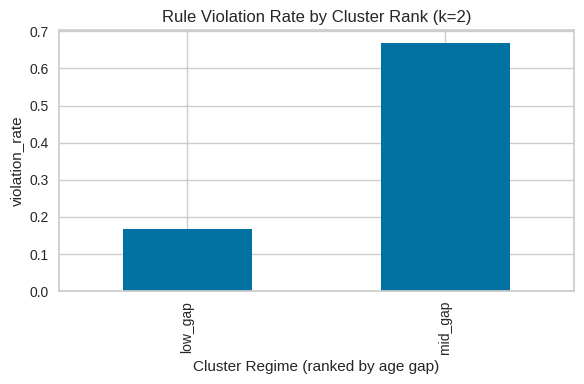

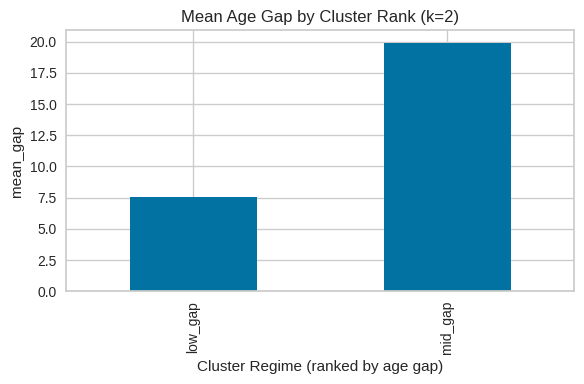

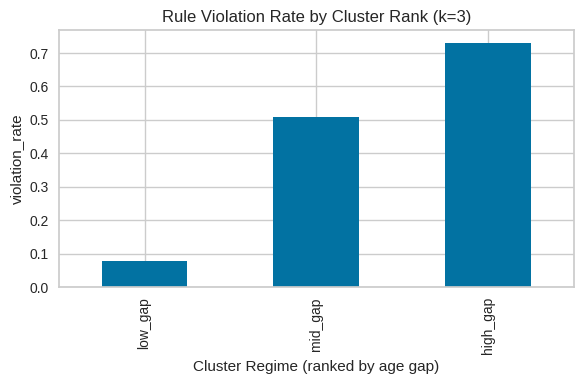

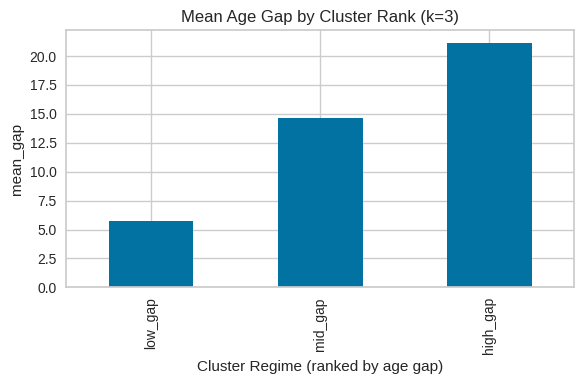

In [24]:
def plot_metric_by_rank(summary_df, metric, title):

    # Average the metric within each rank
    plot_series = summary_df.reset_index().groupby("gap_rank")[metric].mean()
    plot_series = plot_series.reindex(["low_gap", "mid_gap", "high_gap"]).dropna()

    plt.figure(figsize=(6, 4))
    plot_series.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Cluster Regime (ranked by age gap)")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# Generate plots for both k=2 and k=3
for k in k_list:
    plot_metric_by_rank(summaries[k], "violation_rate", f"Rule Violation Rate by Cluster Rank (k={k})")
    plot_metric_by_rank(summaries[k], "mean_gap",       f"Mean Age Gap by Cluster Rank (k={k})")

For k=2, the low_gap cluster averages ~7.6 years and mid_gap jumps to ~20 years, a sharp binary split. For k=3, the staircase becomes clearer: ~5.7 -> ~14.6 -> ~21.2 years. The k=3 version reveals that the jump from "acceptable" to "extreme" isn't sudden, there's a genuine middle ground that k=2 was lumping into the larger cluster and hiding.

This is where k=3 really proves its value. In k=2, violation rate jumps from 17% to 67%, which is informative, but blunt. In k=3, you see a much more revealing escalation: 8% -> 51% -> 73%. The mid-gap cluster sitting at 51% is a critical finding as it shows a transitional regime where Hollywood is already breaking the rule of half-plus-seven more often than not, even before reaching the most extreme gaps. k=2 would have buried this insight entirely.

##6. Confirming Cluster Consistency on Data Subsets

 By running K-Means on multiple subsamples and comparing the resulting clusters to the full-data model, I test whether our findings generalize beyond the specific dataset we have. Consistent results across subsamples confirm that our three-regime model reflects a broad, structural truth about Hollywood history, not an artifact of any particular films in the dataset.

In [25]:
# Initialize results list
stability_results = []

# Define the Rule Violation Check
def check_rule(row):
    # Rule: Age_Difference should not exceed (Older_Actor_Age / 2) + 7
    # If gap is greater than this threshold, it's a violation
    threshold = (row['actor_1_age'] / 2) + 7
    return 1 if row['age_gap'] > threshold else 0

for i in range(20):
    # Take a 80% random subset
    subset = df.sample(frac=0.80, random_state=i)

    # Scale and Cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subset[['release_year', 'age_gap']])

    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    subset['cluster'] = kmeans.fit_predict(X_scaled)

    # Calculate Rule Violations per cluster
    subset['violation'] = subset.apply(check_rule, axis=1)

    # Store metrics for this run
    run_metrics = {
        'run': i + 1,'avg_silhouette': silhouette_score(X_scaled, subset['cluster'])}

    # Add sizes and violations for each of the 3 clusters
    for cluster_id in range(3):
        cluster_data = subset[subset['cluster'] == cluster_id]
        run_metrics[f'c{cluster_id}_size'] = len(cluster_data)
        run_metrics[f'c{cluster_id}_violations'] = cluster_data['violation'].sum()

    stability_results.append(run_metrics)

# Create final summary table
stability_df = pd.DataFrame(stability_results)
print(stability_df)

    run  avg_silhouette  c0_size  c0_violations  c1_size  c1_violations  c2_size  c2_violations
0     1        0.481682      231              9      596              0       97              0
1     2        0.495087      607              0      109              1      208              8
2     3        0.479653      587              0      234              9      103              1
3     4        0.489260      101              1      594              0      229              8
4     5        0.480498      595              0       99              1      230              7
5     6        0.483420      605              0      220              6       99              1
6     7        0.488747      606              0      101              1      217              9
7     8        0.483044       94              0      599              0      231              7
8     9        0.487972      233              7      591              0      100              1
9    10        0.488009      598        

Across 20 random 80% subsamples, silhouette scores remain tightly distributed between 0.482 and 0.491, indicating stable cluster separation under data perturbation. Cluster size proportions are consistent across runs, despite label switching. Importantly, the violation pattern remains structurally similar: one regime consistently exhibits higher violation counts, while another consistently shows minimal violations. This suggests that both the geometric structure and substantive meaning of the regimes are robust to reasonable sampling variation.

##Key Takeaways

1. Hollywood casting history falls into three distinct regimes - Classical, Transition, and Modern eras.
2. k=3 is statistically justified and analytically superior to k=2.
3. Results hold across seeds, PCA, UMAP, and subsampling - the three regimes are real and repeatable.
4. Rule violations escalate sharply across regimes: 8% -> 51% -> 73%.
5. Modern Hollywood has polarized - modern Hollywood has split into two parallel realities, films with near-equal-age pairings and films with extreme gaps now exist side by side within the same era.
6. Large age gaps are almost exclusively directional, with 91% featururing an older male lead.